# Commercial electric bus SOH tables

This notebook lists the four released bus files, loads them, and plots SOH against mileage. It makes no diagnosis.

## 1. Released units

This step lists what `systems('fei_bus')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('fei_bus')
display(released)

,unit,file,bytes
0,vin1,vin1.csv,2366
1,vin5,vin5.csv,3791
2,vin12,vin12.csv,7723
3,vin19,vin19.csv,1667


Each row is one bus. The files are short summary tables, not telemetry.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('fei_bus')
print(frame.shape)
display(frame.head())

(662, 4)


,SOH,SOH(OCV),mileage,unit
0,0.6773,0.7610,41366.1,vin1
1,0.7905,0.8943,41664.3,vin1
2,0.7815,0.9018,41664.3,vin1
3,0.8210,0.9595,42235.7,vin1
4,0.7821,0.9744,43418.8,vin1


All four buses together give 662 SOH estimates with mileage. The release has no timestamps.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['SOH', 'SOH(OCV)', 'mileage']].describe().T)

,count,mean,std,min,25%,50%,75%,max
SOH,662.0,0.838155,0.070590,0.4782,0.789525,0.85325,0.884075,1.0281
SOH(OCV),662.0,0.988377,0.099479,0.7088,0.920500,0.97325,1.053550,1.3421
mileage,662.0,119539.575982,67414.321018,51.7000,63844.625000,112308.20000,164766.500000,262626.6000


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

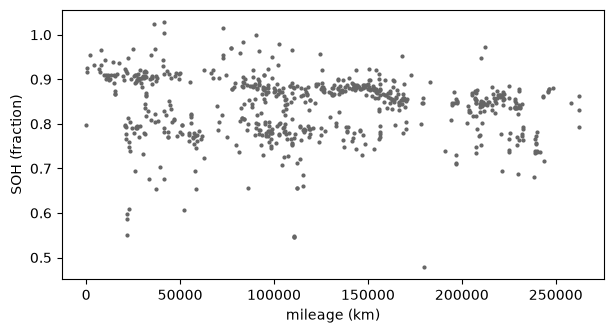

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for unit, group in frame.groupby('unit'):
    ax.plot(group['mileage'], group['SOH'], '.', color='0.4', markersize=4)
ax.set_xlabel('mileage (km)')
ax.set_ylabel('SOH (fraction)')
plt.show()

Across the four buses SOH stays mostly between 0.7 and 0.95 over 260,000 km, with wide scatter between neighbouring estimates and no clear trend in this view. The record does not say how the estimates were made.